# Panel 1

## Noise vs StrucNS - dG 

<ipython-input-3-d3d59f6718b2>:78: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
<ipython-input-3-d3d59f6718b2>:78: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(
<ipython-input-3-d3d59f6718b2>:101: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-3-d3d59f6718b2>:101: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-3-d3d59f6718b2>:101: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-3-d3d59f6718b2>:101: FutureWarning

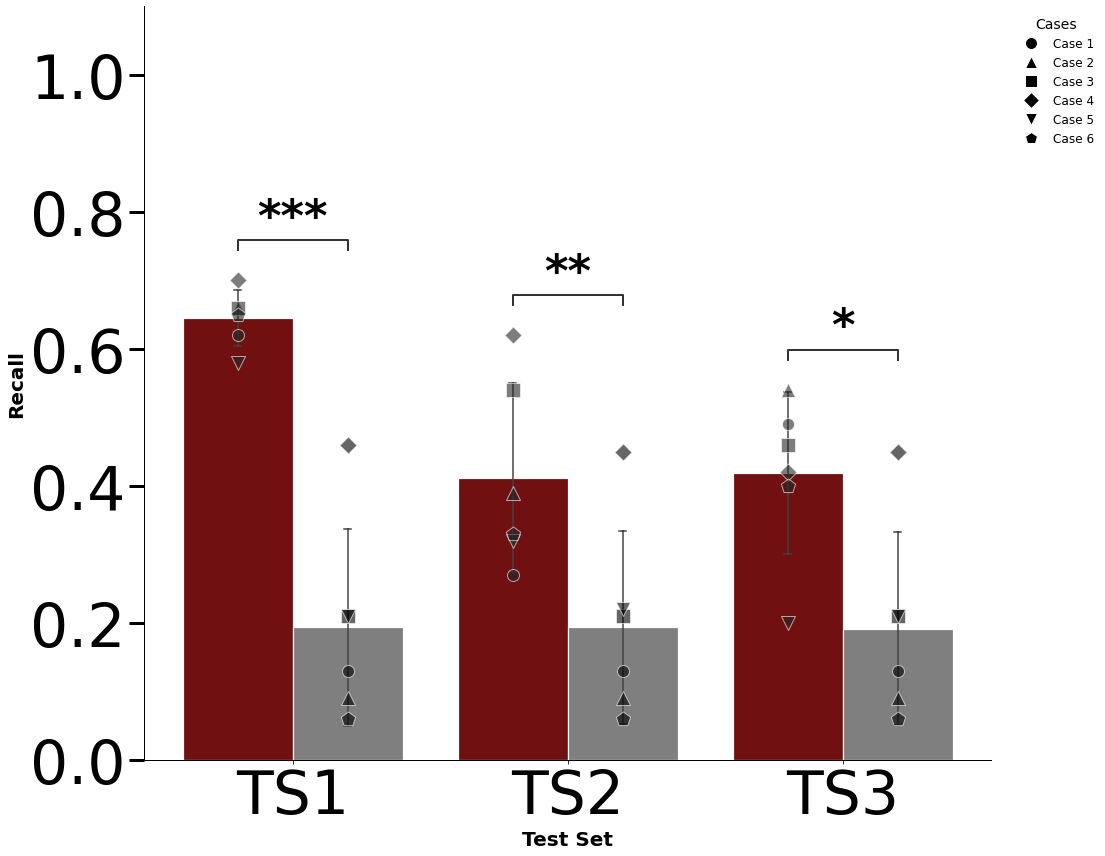

<Figure size 432x288 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
import numpy as np
from itertools import combinations

# ==========================================
# 1. SETUP DATA
# ==========================================

raw_data = {
    'TS1': {
        
        'base_model': [0.62, 0.66, 0.66, 0.7, 0.58, 0.65],
         'noise': [0.13, 0.09, 0.21, 0.46, 0.21, 0.06]
    },
    'TS2': {
        
        'base_model': [0.27, 0.39, 0.54, 0.62, 0.32, 0.33],
        'noise': [0.13, 0.09, 0.21, 0.45, 0.22, 0.06]
    },
    'TS3': {
        
        'base_model': [0.49, 0.54, 0.46, 0.42, 0.2, 0.4],
        'noise': [0.13, 0.09, 0.21, 0.45, 0.21, 0.06]
    },
}

# Convert to DataFrame
data_list = []
for ts, models_dict in raw_data.items():
    for model, scores in models_dict.items():
        for i, score in enumerate(scores):
            # MODIFICATION: Keep the row even if score is None
            # We convert None to np.nan so plotting libraries handle it gracefully
            val = score if score is not None else np.nan
            data_list.append({
                'Test Set': ts, 
                'Model': model, 
                'Precision': val,
                'Run': i 
            })

df = pd.DataFrame(data_list)
# Ensure numeric type
df['Precision'] = pd.to_numeric(df['Precision'], errors='coerce')

# ==========================================
# 2. DEFINE AESTHETICS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.0

models = [ 'base_model','noise' ]

colors_hex = [
    "#800000",  # Maroon (Deep and professional)
    "#7F7F7F",  # Grey (Neutral mid-tone)
]
palette = dict(zip(models, colors_hex))

run_markers = ['o', '^', 's', 'D', 'v', 'p']
run_sizes   = [12, 14, 14, 12, 14, 15] 
run_labels  = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6']

# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(16, 12))

# Optional: Add the dotted line mentioned previously
#plt.axhline(y=0.3, color='black', linestyle=':', linewidth=2, alpha=0.6, zorder=0)

# A. Bar Plot (Base)
ax = sns.barplot(
    data=df, 
    x="Test Set", 
    y="Precision", 
    hue="Model", 
    hue_order=models,
    palette=palette,
    ci='sd',            
    errwidth=1.5,      
    capsize=0.05,      
    edgecolor='white', 
    linewidth=1.2,
    alpha=1
)

# B. Strip Plot Loop (Shapes for Runs)
for run_id in range(6):
    subset = df[df['Run'] == run_id]
    
    # We plot even if values are NaN; seaborn will just skip drawing the point for NaNs
    if subset.empty: 
        continue
        
    sns.stripplot(
        data=subset,
        x="Test Set",
        y="Precision",
        hue="Model",
        hue_order=models,
        dodge=True,      
        jitter=0.15,      
        marker=run_markers[run_id], 
        size=run_sizes[run_id],     
        color='black',   
        alpha=0.6,        
        edgecolor='white',
        linewidth=1,
        ax=ax,
        zorder=10        
    )

# ==========================================
# 4. STATISTICAL ANNOTATION
# ==========================================
try:
    from statannotations.Annotator import Annotator
    
    box_pairs = []
    test_sets = df['Test Set'].unique()
    
    for ts in test_sets:
        models_in_ts = df[df['Test Set'] == ts]['Model'].unique()
        for m1, m2 in combinations(models_in_ts, 2):
            box_pairs.append(((ts, m1), (ts, m2)))

    annotator = Annotator(ax, box_pairs, data=df, x="Test Set", y="Precision", hue="Model")
    
    # MODIFICATION: Changed to 't-test_ind' (Independent)
    # Paired tests fail with missing data. Independent tests handle NaNs by ignoring them.
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', 
                        verbose=0, line_width=2.0)
    annotator.apply_and_annotate()
    
    # Increase Font Size of Stars
    for text_obj in ax.texts:
        txt = text_obj.get_text()
        if '*' in txt or 'ns' in txt:
            text_obj.set_fontsize(45) 
            text_obj.set_fontweight('bold')

except ImportError:
    print("[!] Install statannotations to see significance stars.")

# ==========================================
# 5. LEGENDS AND POLISH
# ==========================================
sns.despine(top=True, right=True)
plt.ylabel("Recall", fontweight='bold', fontsize=20)
plt.xlabel("Test Set", fontweight='bold', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.tick_params(
    axis='y', 
    which='major', 
    direction='out', 
    length=15,    # Increase this to make the "bar" longer
    width=3,     # Increase this to make the "bar" thicker
    labelsize=60 # Keep your existing label size
)
plt.ylim(0, 1.1)

# Legend 1: Models
legend_handles = [mpatches.Patch(color=palette[m], label=m) for m in models]
legend1 = plt.legend(
    handles=legend_handles, 
    title='Models', title_fontsize=14,
    frameon=False, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.2), 
    ncol=3, 
    fontsize=14
)
#ax.add_artist(legend1)

# Legend 2: Cases (Shapes)
shape_handles = []
for i in range(6):
    handle = mlines.Line2D([], [], color='black', marker=run_markers[i], 
                           linestyle='None', markersize=12, label=run_labels[i],
                           markeredgecolor='white', markeredgewidth=1)
    shape_handles.append(handle)

plt.legend(
    handles=shape_handles,
    title='Cases', title_fontsize=14,
    frameon=False,
    loc='upper left',       
    bbox_to_anchor=(1.02, 1), 
    fontsize=12
)

plt.tight_layout()
plt.show()
plt.savefig('figures/Fig3/fig3A.png', dpi=600, bbox_inches='tight')

<ipython-input-4-9f1be580bbd4>:77: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
<ipython-input-4-9f1be580bbd4>:77: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(
<ipython-input-4-9f1be580bbd4>:100: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-4-9f1be580bbd4>:100: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-4-9f1be580bbd4>:100: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-4-9f1be580bbd4>:100: FutureWarning

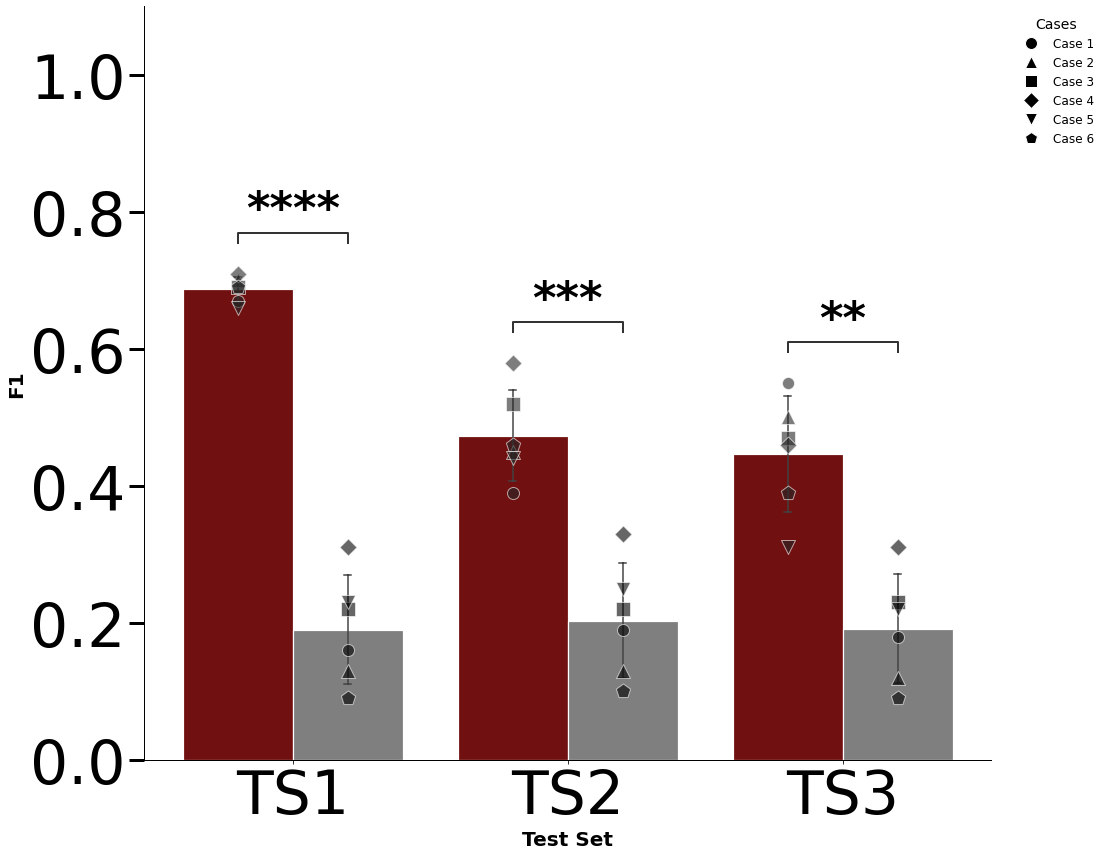

<Figure size 432x288 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
import numpy as np
from itertools import combinations

# ==========================================
# 1. SETUP DATA
# ==========================================

raw_data = {
    'TS1': {
        'noise': [0.16, 0.13, 0.22, 0.31, 0.23, 0.09],
        'base_model': [0.67, 0.7, 0.69, 0.71, 0.66, 0.69]
    },
    'TS2': {
        'noise': [0.19, 0.13, 0.22, 0.33, 0.25, 0.1],
        'base_model': [0.39, 0.45, 0.52, 0.58, 0.44, 0.46]
    },
    'TS3': {
        'noise': [0.18, 0.12, 0.23, 0.31, 0.22, 0.09],
        'base_model': [0.55, 0.5, 0.47, 0.46, 0.31, 0.39]
    },
}



# Convert to DataFrame
data_list = []
for ts, models_dict in raw_data.items():
    for model, scores in models_dict.items():
        for i, score in enumerate(scores):
            # MODIFICATION: Keep the row even if score is None
            # We convert None to np.nan so plotting libraries handle it gracefully
            val = score if score is not None else np.nan
            data_list.append({
                'Test Set': ts, 
                'Model': model, 
                'Precision': val,
                'Run': i 
            })

df = pd.DataFrame(data_list)
# Ensure numeric type
df['Precision'] = pd.to_numeric(df['Precision'], errors='coerce')

# ==========================================
# 2. DEFINE AESTHETICS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.0

models = [ 'base_model', 'noise']

colors_hex = [
    "#800000",  # Maroon (Deep and professional)
    "#7F7F7F",  # Grey (Neutral mid-tone)
]
palette = dict(zip(models, colors_hex))

run_markers = ['o', '^', 's', 'D', 'v', 'p']
run_sizes   = [12, 14, 14, 12, 14, 15] 
run_labels  = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6']

# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(16, 12))

# Optional: Add the dotted line mentioned previously
#plt.axhline(y=0.3, color='black', linestyle=':', linewidth=2, alpha=0.6, zorder=0)

# A. Bar Plot (Base)
ax = sns.barplot(
    data=df, 
    x="Test Set", 
    y="Precision", 
    hue="Model", 
    hue_order=models,
    palette=palette,
    ci='sd',            
    errwidth=1.5,      
    capsize=0.05,      
    edgecolor='white', 
    linewidth=1.2,
    alpha=1
)

# B. Strip Plot Loop (Shapes for Runs)
for run_id in range(6):
    subset = df[df['Run'] == run_id]
    
    # We plot even if values are NaN; seaborn will just skip drawing the point for NaNs
    if subset.empty: 
        continue
        
    sns.stripplot(
        data=subset,
        x="Test Set",
        y="Precision",
        hue="Model",
        hue_order=models,
        dodge=True,      
        jitter=0.15,      
        marker=run_markers[run_id], 
        size=run_sizes[run_id],     
        color='black',   
        alpha=0.6,        
        edgecolor='white',
        linewidth=1,
        ax=ax,
        zorder=10        
    )

# ==========================================
# 4. STATISTICAL ANNOTATION
# ==========================================
try:
    from statannotations.Annotator import Annotator
    
    box_pairs = []
    test_sets = df['Test Set'].unique()
    
    for ts in test_sets:
        models_in_ts = df[df['Test Set'] == ts]['Model'].unique()
        for m1, m2 in combinations(models_in_ts, 2):
            box_pairs.append(((ts, m1), (ts, m2)))

    annotator = Annotator(ax, box_pairs, data=df, x="Test Set", y="Precision", hue="Model")
    
    # MODIFICATION: Changed to 't-test_ind' (Independent)
    # Paired tests fail with missing data. Independent tests handle NaNs by ignoring them.
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', 
                        verbose=0, line_width=2.0)
    annotator.apply_and_annotate()
    
    # Increase Font Size of Stars
    for text_obj in ax.texts:
        txt = text_obj.get_text()
        if '*' in txt or 'ns' in txt:
            text_obj.set_fontsize(45) 
            text_obj.set_fontweight('bold')

except ImportError:
    print("[!] Install statannotations to see significance stars.")

# ==========================================
# 5. LEGENDS AND POLISH
# ==========================================
sns.despine(top=True, right=True)
plt.ylabel("F1", fontweight='bold', fontsize=20)
plt.xlabel("Test Set", fontweight='bold', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.tick_params(
    axis='y', 
    which='major', 
    direction='out', 
    length=15,    # Increase this to make the "bar" longer
    width=3,     # Increase this to make the "bar" thicker
    labelsize=60 # Keep your existing label size
)
plt.ylim(0, 1.1)

# Legend 1: Models
legend_handles = [mpatches.Patch(color=palette[m], label=m) for m in models]
legend1 = plt.legend(
    handles=legend_handles, 
    title='Models', title_fontsize=14,
    frameon=False, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.2), 
    ncol=3, 
    fontsize=14
)
#ax.add_artist(legend1)

# Legend 2: Cases (Shapes)
shape_handles = []
for i in range(6):
    handle = mlines.Line2D([], [], color='black', marker=run_markers[i], 
                           linestyle='None', markersize=12, label=run_labels[i],
                           markeredgecolor='white', markeredgewidth=1)
    shape_handles.append(handle)

plt.legend(
    handles=shape_handles,
    title='Cases', title_fontsize=14,
    frameon=False,
    loc='upper left',       
    bbox_to_anchor=(1.02, 1), 
    fontsize=12
)

plt.tight_layout()
plt.show()
plt.savefig('figures/Fig3/fig3a_2.png', dpi=600, bbox_inches='tight')

# Panel 2

## StrucNS vs zero shot models - ddG - GMean

<ipython-input-5-cb0f1249083a>:100: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
<ipython-input-5-cb0f1249083a>:100: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(
<ipython-input-5-cb0f1249083a>:123: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-5-cb0f1249083a>:123: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-5-cb0f1249083a>:123: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-5-cb0f1249083a>:123: FutureWarni

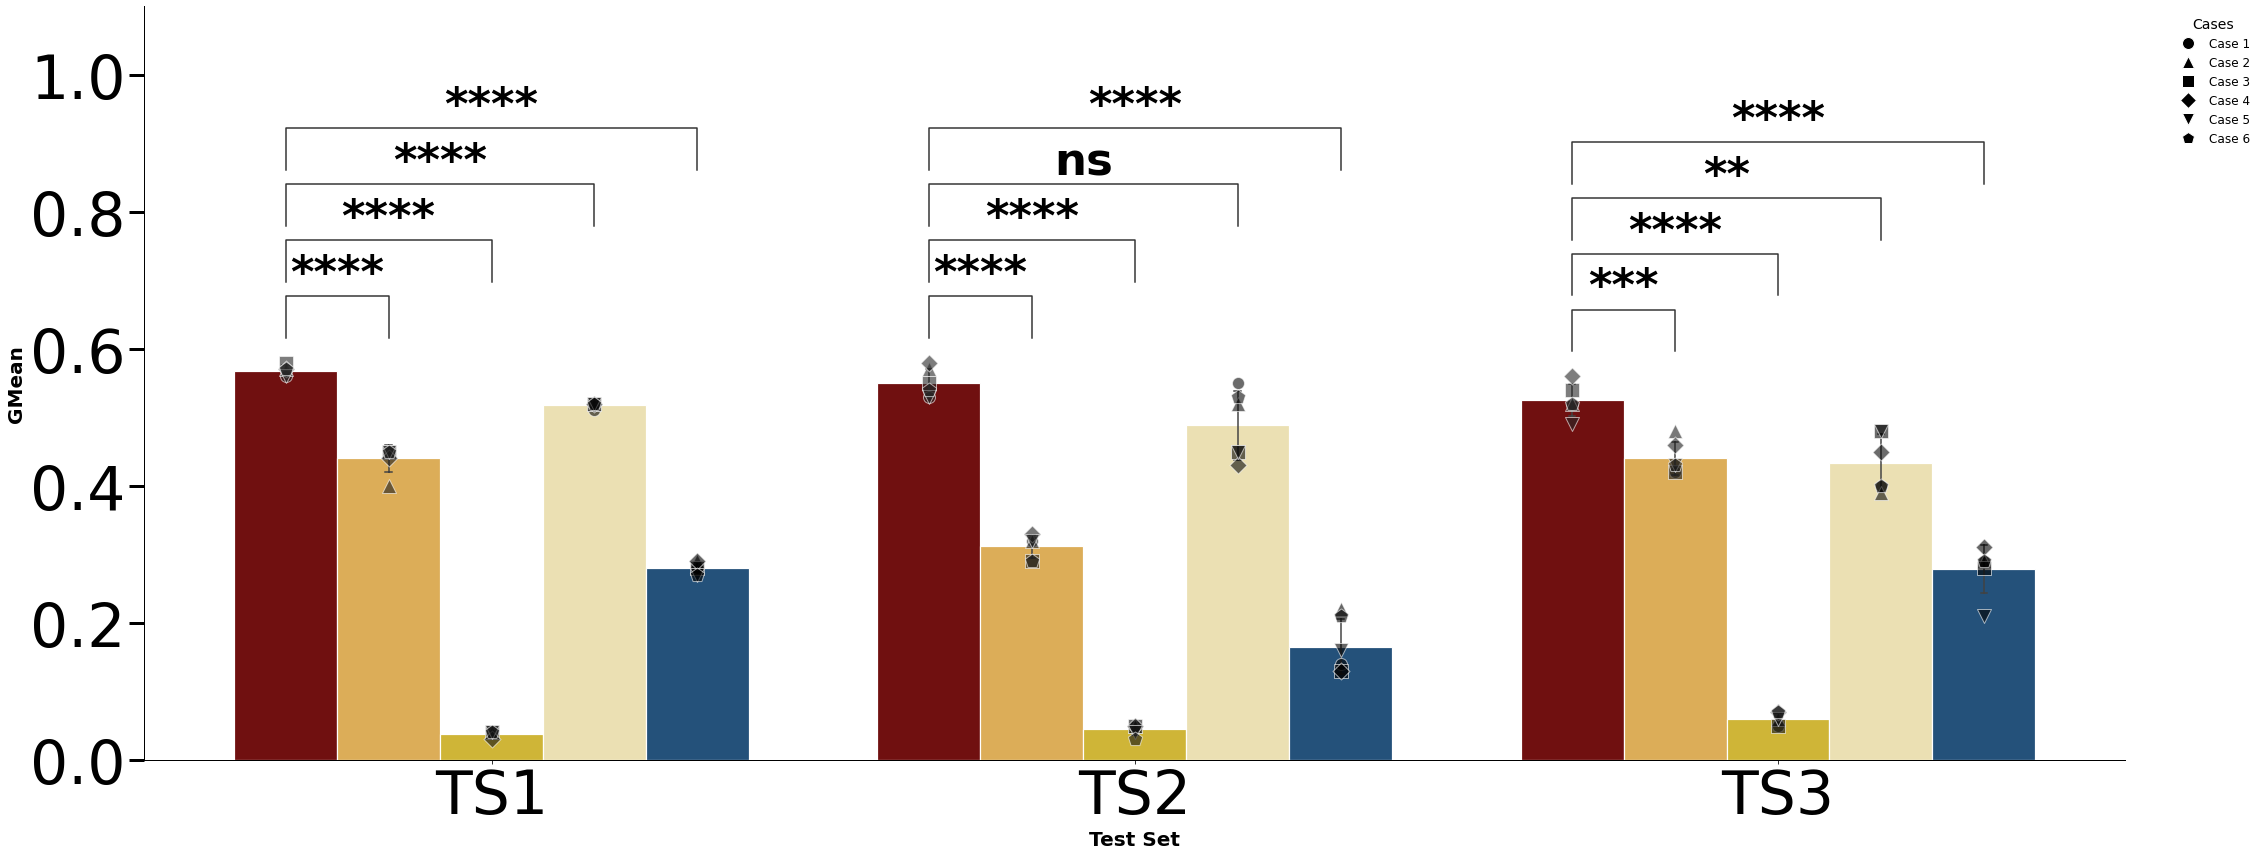

<Figure size 432x288 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
import numpy as np
from itertools import combinations

# ==========================================
# 1. SETUP DATA
# ==========================================

raw_data = {
    'TS1': {
        'base_model': [0.56, 0.57, 0.58, 0.57, 0.56, 0.57],
        'ESM2_zero_shot': [0.45, 0.4, 0.45, 0.44, 0.45, 0.45],
        'ESM_1v': [0.04, 0.04, 0.04, 0.03, 0.04, 0.04],
        'ESM_IF': [0.51, 0.52, 0.52, 0.52, 0.52, 0.52],
        'ProteinMPNN': [0.28, 0.29, 0.28, 0.29, 0.27, 0.27]
    },
    'TS2': {
        'base_model': [0.53, 0.57, 0.55, 0.58, 0.53, 0.54],
        'ESM2_zero_shot': [0.32, 0.32, 0.29, 0.33, 0.32, 0.29],
        'ESM_1v': [0.05, 0.05, 0.05, 0.05, 0.04, 0.03],
        'ESM_IF': [0.55, 0.52, 0.45, 0.43, 0.45, 0.53],
        'ProteinMPNN': [0.14, 0.22, 0.13, 0.13, 0.16, 0.21],
    },
    'TS3': {
        'base_model': [0.52, 0.52, 0.54, 0.56, 0.49, 0.52],
        'ESM2_zero_shot': [0.42, 0.48, 0.42, 0.46, 0.43, 0.43],
        'ESM_1v': [0.05, 0.06, 0.05, 0.07, 0.06, 0.07],
        'ESM_IF': [0.4, 0.39, 0.48, 0.45, 0.48, 0.4],
        'ProteinMPNN': [0.29, 0.29, 0.28, 0.31, 0.21, 0.29],
    },
}


# Convert to DataFrame
data_list = []
for ts, models_dict in raw_data.items():
    for model, scores in models_dict.items():
        for i, score in enumerate(scores):
            # MODIFICATION: Keep the row even if score is None
            # We convert None to np.nan so plotting libraries handle it gracefully
            val = score if score is not None else np.nan
            data_list.append({
                'Test Set': ts, 
                'Model': model, 
                'Precision': val,
                'Run': i 
            })

df = pd.DataFrame(data_list)
# Ensure numeric type
df['Precision'] = pd.to_numeric(df['Precision'], errors='coerce')

# ==========================================
# 2. DEFINE AESTHETICS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.0

models = ['base_model', 'ESM2_zero_shot', 'ESM_1v', 'ESM_IF' ,'ProteinMPNN']



colors_hex = [
    "#800000",  # Maroon
    "#F2B342", 
    "#E9C61D",  
    "#F4E6AA",  
    "#155289",  
]
#colors_hex = [
    #"#E69F00",  # Orange (Fixed first)
    #"#0072B2",  # Blue (High contrast to Orange)
    #"#F0E442",  # Yellow
    #"#CC79A7",  # Reddish Purple
    #"#009E73",  # Bluish Green
    #"#D55E00",  # Vermilion
    #"#56B4E9",  # Sky Blue
    #"#999999"   # Grey
#]
palette = dict(zip(models, colors_hex))

run_markers = ['o', '^', 's', 'D', 'v', 'p']
run_sizes   = [12, 14, 14, 12, 14, 15] 
run_labels  = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6']

# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(32, 12))

# Optional: Add the dotted line mentioned previously
#plt.axhline(y=0.3, color='black', linestyle=':', linewidth=2, alpha=0.6, zorder=0)

# A. Bar Plot (Base)
ax = sns.barplot(
    data=df, 
    x="Test Set", 
    y="Precision", 
    hue="Model", 
    hue_order=models,
    palette=palette,
    ci='sd',            
    errwidth=1.5,      
    capsize=0.05,      
    edgecolor='white', 
    linewidth=1.2,
    alpha=1
)

# B. Strip Plot Loop (Shapes for Runs)
for run_id in range(6):
    subset = df[df['Run'] == run_id]
    
    # We plot even if values are NaN; seaborn will just skip drawing the point for NaNs
    if subset.empty: 
        continue
        
    sns.stripplot(
        data=subset,
        x="Test Set",
        y="Precision",
        hue="Model",
        hue_order=models,
        dodge=True,      
        jitter=0.15,      
        marker=run_markers[run_id], 
        size=run_sizes[run_id],     
        color='black',   
        alpha=0.6,        
        edgecolor='white',
        linewidth=1,
        ax=ax,
        zorder=10        
    )

# ==========================================
# 4. STATISTICAL ANNOTATION (Modified)
# ==========================================
try:
    from statannotations.Annotator import Annotator
    
    box_pairs = []
    test_sets = df['Test Set'].unique()
    
    # Define your control model
    control_model = 'base_model' 
    # List of models to compare against the control
    other_models = [m for m in models if m != control_model]
    
    for ts in test_sets:
        for other in other_models:
            # Only create pairs that involve the base_model
            box_pairs.append(((ts, control_model), (ts, other)))

    annotator = Annotator(ax, box_pairs, data=df, x="Test Set", y="Precision", hue="Model")
    
    # Using t-test_ind as it's more robust for general comparisons
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', 
                        # --- ADD THESE PARAMETERS ---
                        line_offset=0,        # Gap between the bracket and the stars/text
                        line_offset_to_group=0.05, # Gap between the top of the bar/points and the first bracket
                        line_height=0.1,          # Gap between multiple stacked brackets
                        # ----------------------------
                        verbose=0, line_width=1.5)
    annotator.apply_and_annotate()
    
    # Styling the stars
    for text_obj in ax.texts:
        txt = text_obj.get_text()
        if '*' in txt or 'ns' in txt:
            text_obj.set_fontsize(45) # Slightly smaller to avoid overlap
            text_obj.set_fontweight('bold')

except ImportError:
    print("[!] Install statannotations to see significance stars.")

# ==========================================
# 5. LEGENDS AND POLISH
# ==========================================
sns.despine(top=True, right=True)
plt.ylabel("GMean", fontweight='bold', fontsize=20)
plt.xlabel("Test Set", fontweight='bold', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.tick_params(
    axis='y', 
    which='major', 
    direction='out', 
    length=15,    # Increase this to make the "bar" longer
    width=3,     # Increase this to make the "bar" thicker
    labelsize=60 # Keep your existing label size
)
plt.ylim(0, 1.1)

# Legend 1: Models
legend_handles = [mpatches.Patch(color=palette[m], label=m) for m in models]
legend1 = plt.legend(
    handles=legend_handles, 
    title='Models', title_fontsize=14,
    frameon=False, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.2), 
    ncol=3, 
    fontsize=14
)
#ax.add_artist(legend1)

# Legend 2: Cases (Shapes)
shape_handles = []
for i in range(6):
    handle = mlines.Line2D([], [], color='black', marker=run_markers[i], 
                           linestyle='None', markersize=12, label=run_labels[i],
                           markeredgecolor='white', markeredgewidth=1)
    shape_handles.append(handle)

plt.legend(
    handles=shape_handles,
    title='Cases', title_fontsize=14,
    frameon=False,
    loc='upper left',       
    bbox_to_anchor=(1.02, 1), 
    fontsize=12
)

plt.tight_layout()
plt.show()
plt.savefig('figures/Fig3/fig3b_GM_ddg_comparison.png', dpi=600, bbox_inches='tight')

# Panel 3

## StrucNS vs ThermoMPNN - ddG - GMean - Maybe Spurs

<ipython-input-6-0eaf53108355>:79: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
<ipython-input-6-0eaf53108355>:79: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(
<ipython-input-6-0eaf53108355>:102: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-6-0eaf53108355>:102: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-6-0eaf53108355>:102: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-6-0eaf53108355>:102: FutureWarning

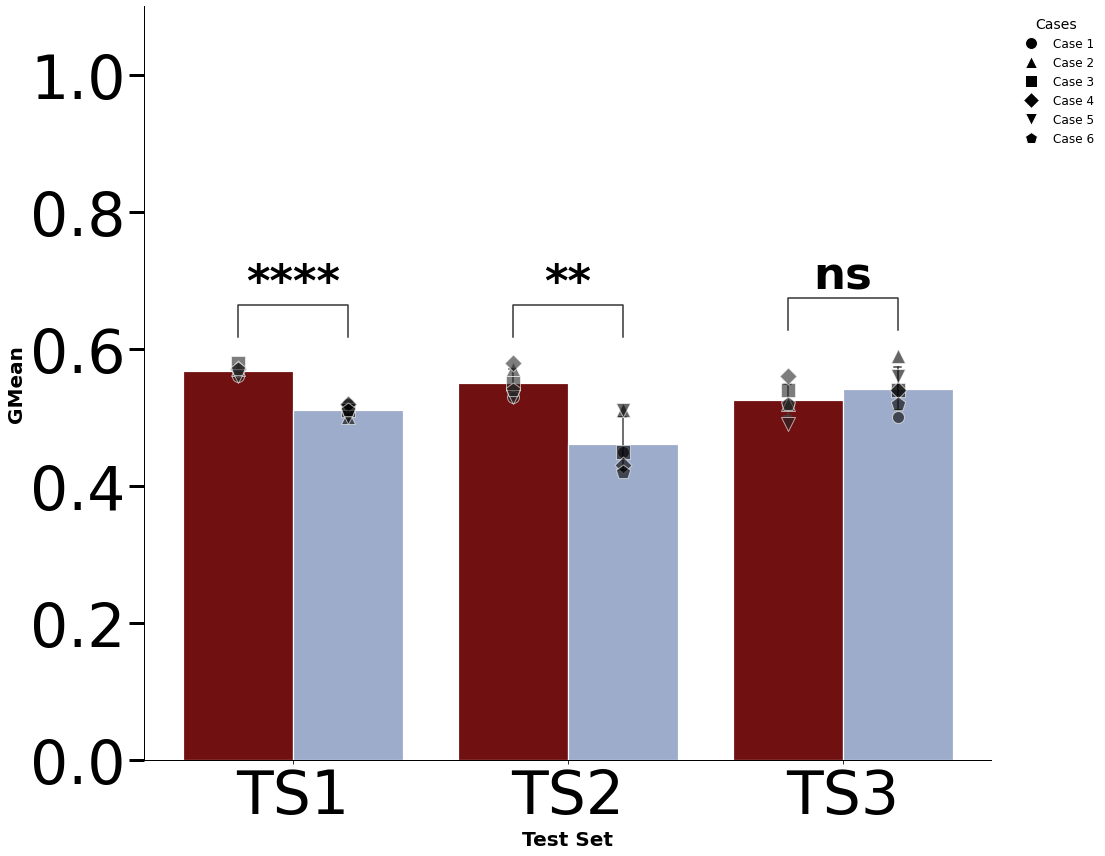

<Figure size 432x288 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
import numpy as np
from itertools import combinations


# ==========================================
# 1. SETUP DATA
# ==========================================

raw_data = {
    'TS1': {
        'base_model': [0.56, 0.57, 0.58, 0.57, 0.56, 0.57],
        'ThermoMPNN-D': [0.52, 0.5, 0.51, 0.52, 0.5, 0.51]
    },
    'TS2': {
        'base_model': [0.53, 0.57, 0.55, 0.58, 0.53, 0.54],
        'ThermoMPNN-D': [0.45, 0.51, 0.45, 0.43, 0.51, 0.42]
    },
    'TS3': {
        'base_model': [0.52, 0.52, 0.54, 0.56, 0.49, 0.52],
        'ThermoMPNN-D': [0.5, 0.59, 0.54, 0.54, 0.56, 0.52]
    },
}


# Convert to DataFrame
data_list = []
for ts, models_dict in raw_data.items():
    for model, scores in models_dict.items():
        for i, score in enumerate(scores):
            # MODIFICATION: Keep the row even if score is None
            # We convert None to np.nan so plotting libraries handle it gracefully
            val = score if score is not None else np.nan
            data_list.append({
                'Test Set': ts, 
                'Model': model, 
                'Precision': val,
                'Run': i 
            })

df = pd.DataFrame(data_list)
# Ensure numeric type
df['Precision'] = pd.to_numeric(df['Precision'], errors='coerce')

# ==========================================
# 2. DEFINE AESTHETICS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.0

models = ['base_model', 'ThermoMPNN-D']

colors_hex = [
    
    "#800000",  
    "#95AAD3",  
]    

palette = dict(zip(models, colors_hex))

run_markers = ['o', '^', 's', 'D', 'v', 'p']
run_sizes   = [12, 14, 14, 12, 14, 15] 
run_labels  = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6']

# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(16, 12))

# Optional: Add the dotted line mentioned previously
#plt.axhline(y=0.3, color='black', linestyle=':', linewidth=2, alpha=0.6, zorder=0)

# A. Bar Plot (Base)
ax = sns.barplot(
    data=df, 
    x="Test Set", 
    y="Precision", 
    hue="Model", 
    hue_order=models,
    palette=palette,
    ci='sd',            
    errwidth=1.5,      
    capsize=0.05,      
    edgecolor='white', 
    linewidth=1.2,
    alpha=1
)

# B. Strip Plot Loop (Shapes for Runs)
for run_id in range(6):
    subset = df[df['Run'] == run_id]
    
    # We plot even if values are NaN; seaborn will just skip drawing the point for NaNs
    if subset.empty: 
        continue
        
    sns.stripplot(
        data=subset,
        x="Test Set",
        y="Precision",
        hue="Model",
        hue_order=models,
        dodge=True,      
        jitter=0.15,      
        marker=run_markers[run_id], 
        size=run_sizes[run_id],     
        color='black',   
        alpha=0.6,        
        edgecolor='white',
        linewidth=1,
        ax=ax,
        zorder=10        
    )

# ==========================================
# 4. STATISTICAL ANNOTATION (Modified)
# ==========================================
try:
    from statannotations.Annotator import Annotator
    
    box_pairs = []
    test_sets = df['Test Set'].unique()
    
    # Define your control model
    control_model = 'base_model' 
    # List of models to compare against the control
    other_models = [m for m in models if m != control_model]
    
    for ts in test_sets:
        for other in other_models:
            # Only create pairs that involve the base_model
            box_pairs.append(((ts, control_model), (ts, other)))

    annotator = Annotator(ax, box_pairs, data=df, x="Test Set", y="Precision", hue="Model")
    
    # Using t-test_ind as it's more robust for general comparisons
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', 
                        # --- ADD THESE PARAMETERS ---
                        line_offset=0,        # Gap between the bracket and the stars/text
                        line_offset_to_group=0.1, # Gap between the top of the bar/points and the first bracket
                        line_height=0.075,          # Gap between multiple stacked brackets
                        # ----------------------------
                        verbose=0, line_width=1.5)
    annotator.apply_and_annotate()
    
    # Styling the stars
    for text_obj in ax.texts:
        txt = text_obj.get_text()
        if '*' in txt or 'ns' in txt:
            text_obj.set_fontsize(45) # Slightly smaller to avoid overlap
            text_obj.set_fontweight('bold')

except ImportError:
    print("[!] Install statannotations to see significance stars.")


# ==========================================
# 5. LEGENDS AND POLISH
# ==========================================
sns.despine(top=True, right=True)
plt.ylabel("GMean", fontweight='bold', fontsize=20)
plt.xlabel("Test Set", fontweight='bold', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.tick_params(
    axis='y', 
    which='major', 
    direction='out', 
    length=15,    # Increase this to make the "bar" longer
    width=3,     # Increase this to make the "bar" thicker
    labelsize=60 # Keep your existing label size
)
plt.ylim(0, 1.1)

# Legend 1: Models
legend_handles = [mpatches.Patch(color=palette[m], label=m) for m in models]
legend1 = plt.legend(
    handles=legend_handles, 
    title='Models', title_fontsize=14,
    frameon=False, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.2), 
    ncol=3, 
    fontsize=14
)
#ax.add_artist(legend1)

# Legend 2: Cases (Shapes)
shape_handles = []
for i in range(6):
    handle = mlines.Line2D([], [], color='black', marker=run_markers[i], 
                           linestyle='None', markersize=12, label=run_labels[i],
                           markeredgecolor='white', markeredgewidth=1)
    shape_handles.append(handle)

plt.legend(
    handles=shape_handles,
    title='Cases', title_fontsize=14,
    frameon=False,
    loc='upper left',       
    bbox_to_anchor=(1.02, 1), 
    fontsize=12
)

plt.tight_layout()
plt.show()
plt.savefig('figures/Fig3/fig_3c_GM_ddg_comparison.png', dpi=600, bbox_inches='tight')

# Panel d

## StrucNS vs supervised model - dG

## Recall

<ipython-input-8-19e0ec6c9afa>:84: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
<ipython-input-8-19e0ec6c9afa>:84: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(
<ipython-input-8-19e0ec6c9afa>:107: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-8-19e0ec6c9afa>:107: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-8-19e0ec6c9afa>:107: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-8-19e0ec6c9afa>:107: FutureWarning

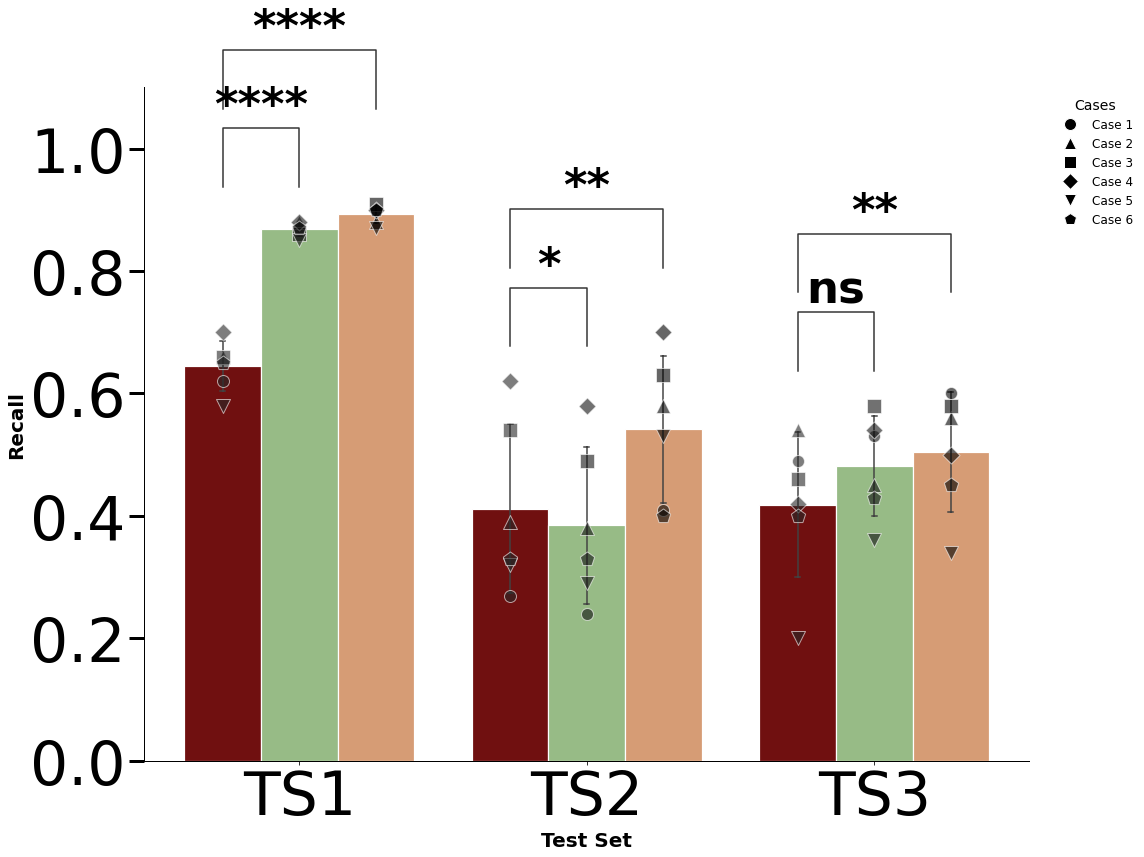

<Figure size 432x288 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
import numpy as np
from itertools import combinations

# ==========================================
# 1. SETUP DATA
# ==========================================

raw_data = {
    'TS1': {
        
        'base_model': [0.62, 0.66, 0.66, 0.7, 0.58, 0.65],
        'Unirep-S': [0.87, 0.88, 0.86, 0.88, 0.85, 0.87],
        'ESM2-S': [0.9, 0.88, 0.91, 0.9, 0.87, 0.9]
    },
    'TS2': {
        
        'base_model': [0.27, 0.39, 0.54, 0.62, 0.32, 0.33],
        'Unirep-S': [0.24, 0.38, 0.49, 0.58, 0.29, 0.33],
        'ESM2-S': [0.41, 0.58, 0.63, 0.7, 0.53, 0.4]
    },
    'TS3': {
        
        'base_model': [0.49, 0.54, 0.46, 0.42, 0.2, 0.4],
        'Unirep-S': [0.53, 0.45, 0.58, 0.54, 0.36, 0.43],
        'ESM2-S': [0.6, 0.56, 0.58, 0.5, 0.34, 0.45]
    },
}

# Convert to DataFrame
data_list = []
for ts, models_dict in raw_data.items():
    for model, scores in models_dict.items():
        for i, score in enumerate(scores):
            # MODIFICATION: Keep the row even if score is None
            # We convert None to np.nan so plotting libraries handle it gracefully
            val = score if score is not None else np.nan
            data_list.append({
                'Test Set': ts, 
                'Model': model, 
                'Precision': val,
                'Run': i 
            })

df = pd.DataFrame(data_list)
# Ensure numeric type
df['Precision'] = pd.to_numeric(df['Precision'], errors='coerce')

# ==========================================
# 2. DEFINE AESTHETICS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.0

models = ['base_model', 'Unirep-S', 'ESM2-S']

colors_hex = [
    
    "#800000",  
    "#94C47D",  
    "#E69965"
    
]
palette = dict(zip(models, colors_hex))

run_markers = ['o', '^', 's', 'D', 'v', 'p']
run_sizes   = [12, 14, 14, 12, 14, 15] 
run_labels  = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6']

# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(16, 12))

# Optional: Add the dotted line mentioned previously
#plt.axhline(y=0.3, color='black', linestyle=':', linewidth=2, alpha=0.6, zorder=0)

# A. Bar Plot (Base)
ax = sns.barplot(
    data=df, 
    x="Test Set", 
    y="Precision", 
    hue="Model", 
    hue_order=models,
    palette=palette,
    ci='sd',            
    errwidth=1.5,      
    capsize=0.05,      
    edgecolor='white', 
    linewidth=1.2,
    alpha=1
)

# B. Strip Plot Loop (Shapes for Runs)
for run_id in range(6):
    subset = df[df['Run'] == run_id]
    
    # We plot even if values are NaN; seaborn will just skip drawing the point for NaNs
    if subset.empty: 
        continue
        
    sns.stripplot(
        data=subset,
        x="Test Set",
        y="Precision",
        hue="Model",
        hue_order=models,
        dodge=True,      
        jitter=0.15,      
        marker=run_markers[run_id], 
        size=run_sizes[run_id],     
        color='black',   
        alpha=0.6,        
        edgecolor='white',
        linewidth=1,
        ax=ax,
        zorder=10        
    )

# ==========================================
# 4. STATISTICAL ANNOTATION (Modified)
# ==========================================
try:
    from statannotations.Annotator import Annotator
    
    box_pairs = []
    test_sets = df['Test Set'].unique()
    
    # Define your control model
    control_model = 'base_model' 
    # List of models to compare against the control
    other_models = [m for m in models if m != control_model]
    
    for ts in test_sets:
        for other in other_models:
            # Only create pairs that involve the base_model
            box_pairs.append(((ts, control_model), (ts, other)))

    annotator = Annotator(ax, box_pairs, data=df, x="Test Set", y="Precision", hue="Model")
    
    # Using t-test_ind as it's more robust for general comparisons
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', 
                        # --- ADD THESE PARAMETERS ---
                        line_offset=0,        # Gap between the bracket and the stars/text
                        line_offset_to_group=0.05, # Gap between the top of the bar/points and the first bracket
                        line_height=0.1,          # Gap between multiple stacked brackets
                        # ----------------------------
                        verbose=0, line_width=1.5)
    annotator.apply_and_annotate()
    
    # Styling the stars
    for text_obj in ax.texts:
        txt = text_obj.get_text()
        if '*' in txt or 'ns' in txt:
            text_obj.set_fontsize(45) # Slightly smaller to avoid overlap
            text_obj.set_fontweight('bold')

except ImportError:
    print("[!] Install statannotations to see significance stars.")
# ==========================================
# 5. LEGENDS AND POLISH
# ==========================================
sns.despine(top=True, right=True)
plt.ylabel("Recall", fontweight='bold', fontsize=20)
plt.xlabel("Test Set", fontweight='bold', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.tick_params(
    axis='y', 
    which='major', 
    direction='out', 
    length=15,    # Increase this to make the "bar" longer
    width=3,     # Increase this to make the "bar" thicker
    labelsize=60 # Keep your existing label size
)
plt.ylim(0, 1.1)
plt.yticks(np.arange(0, 1.1, 0.2))
# Legend 1: Models
legend_handles = [mpatches.Patch(color=palette[m], label=m) for m in models]
legend1 = plt.legend(
    handles=legend_handles, 
    title='Models', title_fontsize=14,
    frameon=False, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.2), 
    ncol=3, 
    fontsize=14
)
#ax.add_artist(legend1)

# Legend 2: Cases (Shapes)
shape_handles = []
for i in range(6):
    handle = mlines.Line2D([], [], color='black', marker=run_markers[i], 
                           linestyle='None', markersize=12, label=run_labels[i],
                           markeredgecolor='white', markeredgewidth=1)
    shape_handles.append(handle)

plt.legend(
    handles=shape_handles,
    title='Cases', title_fontsize=14,
    frameon=False,
    loc='upper left',       
    bbox_to_anchor=(1.02, 1), 
    fontsize=12
)

plt.tight_layout()
plt.show()
plt.savefig('figures/Fig3/fig3e_2_recall_model_comparison.png', dpi=600, bbox_inches='tight')

## F1

<ipython-input-9-c49cd8a5978a>:86: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
<ipython-input-9-c49cd8a5978a>:86: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(
<ipython-input-9-c49cd8a5978a>:109: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-9-c49cd8a5978a>:109: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-9-c49cd8a5978a>:109: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-9-c49cd8a5978a>:109: FutureWarning

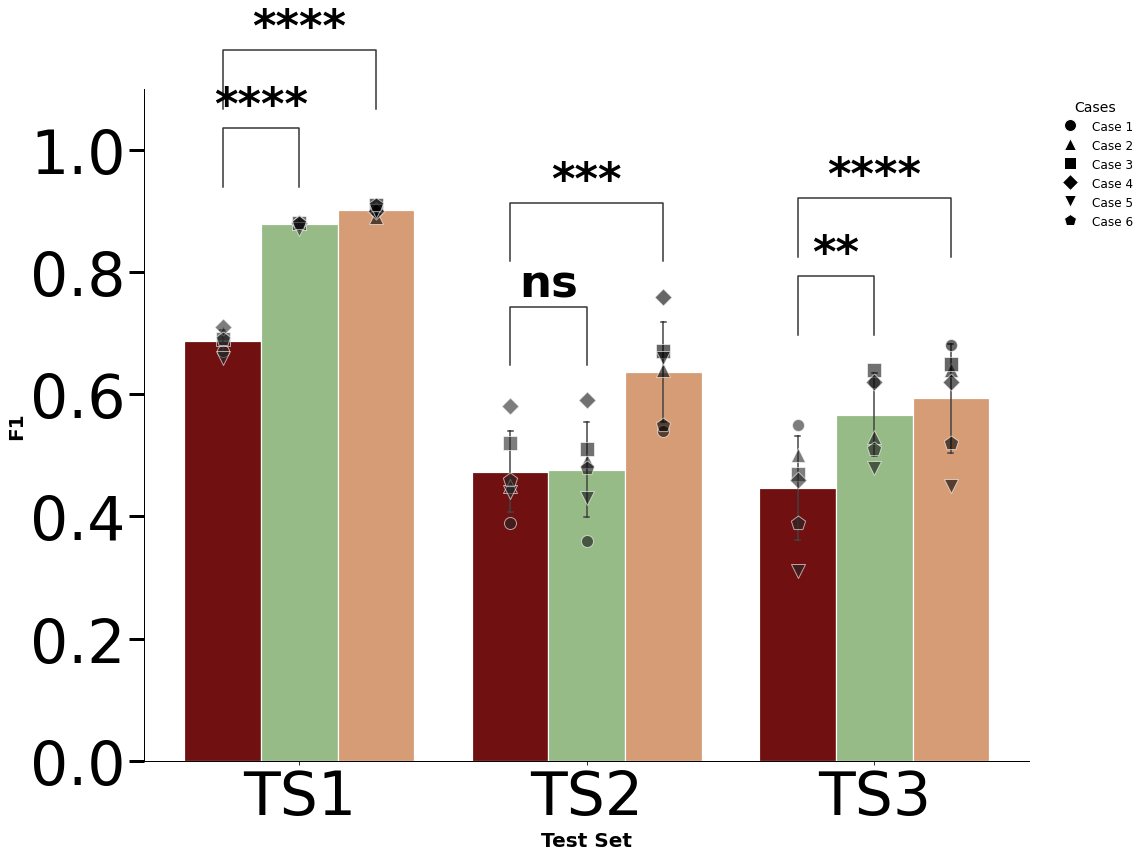

<Figure size 432x288 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
import numpy as np
from itertools import combinations

# ==========================================
# 1. SETUP DATA
# ==========================================

raw_data = {
    'TS1': {
        
        'base_model': [0.67, 0.7, 0.69, 0.71, 0.66, 0.69],
        'Unirep': [0.88, 0.88, 0.88, 0.88, 0.87, 0.88],
        'ESM2': [0.9, 0.89, 0.91, 0.9, 0.9, 0.91],
    },
    'TS2': {
  
        'base_model': [0.39, 0.45, 0.52, 0.58, 0.44, 0.46],
        'Unirep': [0.36, 0.49, 0.51, 0.59, 0.43, 0.48],
        'ESM2': [0.54, 0.64, 0.67, 0.76, 0.66, 0.55],
    },
    'TS3': {
        
        'base_model': [0.55, 0.5, 0.47, 0.46, 0.31, 0.39],
        'Unirep': [0.62, 0.53, 0.64, 0.62, 0.48, 0.51],
        'ESM2': [0.68, 0.64, 0.65, 0.62, 0.45, 0.52],
    },
}



# Convert to DataFrame
data_list = []
for ts, models_dict in raw_data.items():
    for model, scores in models_dict.items():
        for i, score in enumerate(scores):
            # MODIFICATION: Keep the row even if score is None
            # We convert None to np.nan so plotting libraries handle it gracefully
            val = score if score is not None else np.nan
            data_list.append({
                'Test Set': ts, 
                'Model': model, 
                'Precision': val,
                'Run': i 
            })

df = pd.DataFrame(data_list)
# Ensure numeric type
df['Precision'] = pd.to_numeric(df['Precision'], errors='coerce')

# ==========================================
# 2. DEFINE AESTHETICS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.0

models = ['base_model', 'Unirep', 'ESM2']

colors_hex = [
    
    "#800000",  
    "#94C47D",  
    "#E69965"
    
]
palette = dict(zip(models, colors_hex))

run_markers = ['o', '^', 's', 'D', 'v', 'p']
run_sizes   = [12, 14, 14, 12, 14, 15] 
run_labels  = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6']

# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(16, 12))

# Optional: Add the dotted line mentioned previously
#plt.axhline(y=0.3, color='black', linestyle=':', linewidth=2, alpha=0.6, zorder=0)

# A. Bar Plot (Base)
ax = sns.barplot(
    data=df, 
    x="Test Set", 
    y="Precision", 
    hue="Model", 
    hue_order=models,
    palette=palette,
    ci='sd',            
    errwidth=1.5,      
    capsize=0.05,      
    edgecolor='white', 
    linewidth=1.2,
    alpha=1
)

# B. Strip Plot Loop (Shapes for Runs)
for run_id in range(6):
    subset = df[df['Run'] == run_id]
    
    # We plot even if values are NaN; seaborn will just skip drawing the point for NaNs
    if subset.empty: 
        continue
        
    sns.stripplot(
        data=subset,
        x="Test Set",
        y="Precision",
        hue="Model",
        hue_order=models,
        dodge=True,      
        jitter=0.15,      
        marker=run_markers[run_id], 
        size=run_sizes[run_id],     
        color='black',   
        alpha=0.6,        
        edgecolor='white',
        linewidth=1,
        ax=ax,
        zorder=10        
    )

# ==========================================
# 4. STATISTICAL ANNOTATION (Modified)
# ==========================================
try:
    from statannotations.Annotator import Annotator
    
    box_pairs = []
    test_sets = df['Test Set'].unique()
    
    # Define your control model
    control_model = 'base_model' 
    # List of models to compare against the control
    other_models = [m for m in models if m != control_model]
    
    for ts in test_sets:
        for other in other_models:
            # Only create pairs that involve the base_model
            box_pairs.append(((ts, control_model), (ts, other)))

    annotator = Annotator(ax, box_pairs, data=df, x="Test Set", y="Precision", hue="Model")
    
    # Using t-test_ind as it's more robust for general comparisons
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', 
                        # --- ADD THESE PARAMETERS ---
                        line_offset=0,        # Gap between the bracket and the stars/text
                        line_offset_to_group=0.1, # Gap between the top of the bar/points and the first bracket
                        line_height=0.1,          # Gap between multiple stacked brackets
                        # ----------------------------
                        verbose=0, line_width=1.5)
    annotator.apply_and_annotate()
    
    # Styling the stars
    for text_obj in ax.texts:
        txt = text_obj.get_text()
        if '*' in txt or 'ns' in txt:
            text_obj.set_fontsize(45) # Slightly smaller to avoid overlap
            text_obj.set_fontweight('bold')

except ImportError:
    print("[!] Install statannotations to see significance stars.")

# ==========================================
# 5. LEGENDS AND POLISH
# ==========================================
sns.despine(top=True, right=True)
plt.ylabel("F1", fontweight='bold', fontsize=20)
plt.xlabel("Test Set", fontweight='bold', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.tick_params(
    axis='y', 
    which='major', 
    direction='out', 
    length=15,    # Increase this to make the "bar" longer
    width=3,     # Increase this to make the "bar" thicker
    labelsize=60 # Keep your existing label size
)
plt.ylim(0, 1.1)
plt.yticks(np.arange(0, 1.1, 0.2))
# Legend 1: Models
legend_handles = [mpatches.Patch(color=palette[m], label=m) for m in models]
legend1 = plt.legend(
    handles=legend_handles, 
    title='Models', title_fontsize=14,
    frameon=False, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.2), 
    ncol=3, 
    fontsize=14
)
#ax.add_artist(legend1)

# Legend 2: Cases (Shapes)
shape_handles = []
for i in range(6):
    handle = mlines.Line2D([], [], color='black', marker=run_markers[i], 
                           linestyle='None', markersize=12, label=run_labels[i],
                           markeredgecolor='white', markeredgewidth=1)
    shape_handles.append(handle)

plt.legend(
    handles=shape_handles,
    title='Cases', title_fontsize=14,
    frameon=False,
    loc='upper left',       
    bbox_to_anchor=(1.02, 1), 
    fontsize=12
)

plt.tight_layout()
plt.show()
plt.savefig('figures/Fig3/fig3e_3_f1_model_comparison.png', dpi=600, bbox_inches='tight')

## StrucNS vs supervised model - ddG

<ipython-input-10-2e03e8867165>:92: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
<ipython-input-10-2e03e8867165>:92: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(
<ipython-input-10-2e03e8867165>:115: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-10-2e03e8867165>:115: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-10-2e03e8867165>:115: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-10-2e03e8867165>:115: FutureW

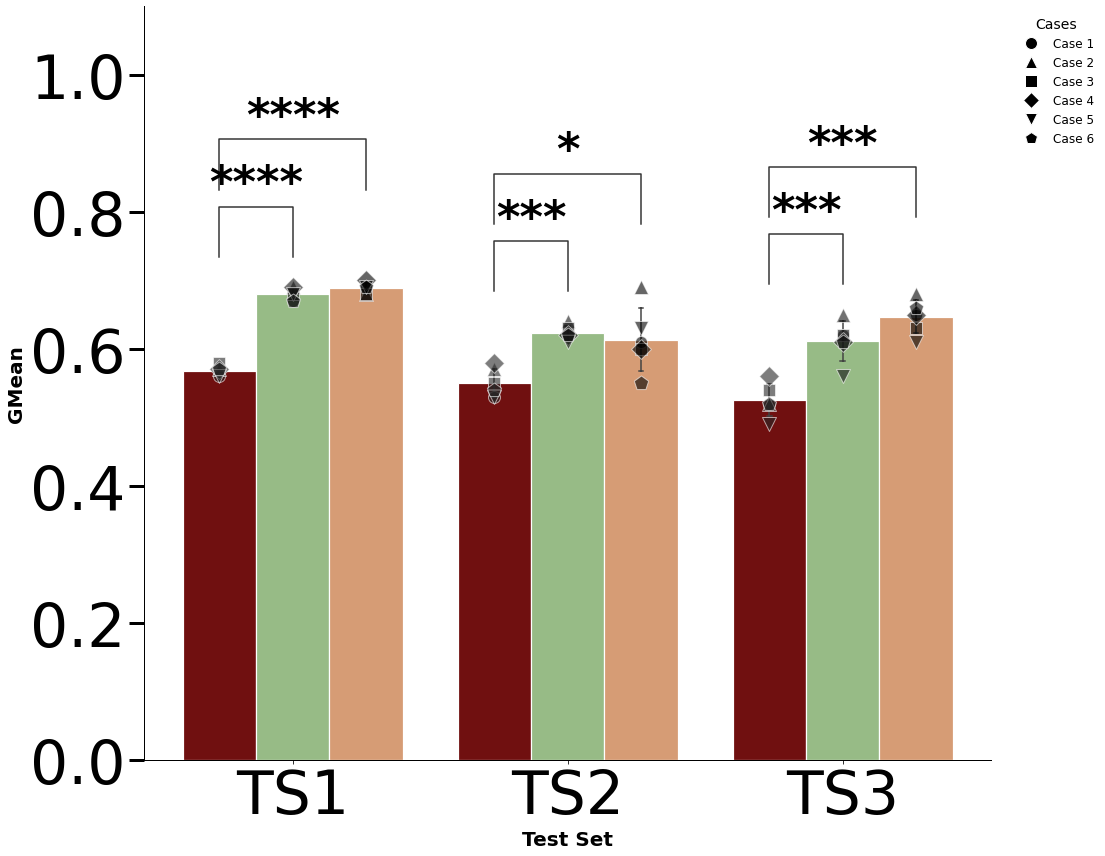

<Figure size 432x288 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
import numpy as np
from itertools import combinations

# ==========================================
# 1. SETUP DATA
# ==========================================

raw_data = {
    'TS1': {
        'base_model': [0.56, 0.57, 0.58, 0.57, 0.56, 0.57],
        'Unirep-S': [0.67, 0.69, 0.68, 0.69, 0.68, 0.67],
        'ESM2-S': [0.69, 0.68, 0.68, 0.7, 0.69, 0.69]
    },
    'TS2': {
        'base_model': [0.53, 0.57, 0.55, 0.58, 0.53, 0.54],
        'Unirep-S': [0.62, 0.64, 0.63, 0.62, 0.61, 0.62],
        'ESM2-S': [0.61, 0.69, 0.6, 0.6, 0.63, 0.55]
    },
    'TS3': {
        'base_model': [0.52, 0.52, 0.54, 0.56, 0.49, 0.52],
        'Unirep-S': [0.62, 0.65, 0.62, 0.61, 0.56, 0.61],
        'ESM2-S': [0.65, 0.68, 0.63, 0.65, 0.61, 0.66]
    },
}


# Convert to DataFrame
data_list = []
for ts, models_dict in raw_data.items():
    for model, scores in models_dict.items():
        for i, score in enumerate(scores):
            # MODIFICATION: Keep the row even if score is None
            # We convert None to np.nan so plotting libraries handle it gracefully
            val = score if score is not None else np.nan
            data_list.append({
                'Test Set': ts, 
                'Model': model, 
                'Precision': val,
                'Run': i 
            })

df = pd.DataFrame(data_list)
# Ensure numeric type
df['Precision'] = pd.to_numeric(df['Precision'], errors='coerce')

# ==========================================
# 2. DEFINE AESTHETICS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.0

models = ['base_model', 'Unirep-S', 'ESM2-S']

colors_hex = [
    
    "#800000",  
    "#94C47D",  
    "#E69965"
    
]
#colors_hex = [
    #"#E69F00",  # Orange (Fixed first)
    #"#0072B2",  # Blue (High contrast to Orange)
    #"#F0E442",  # Yellow
    #"#CC79A7",  # Reddish Purple
    #"#009E73",  # Bluish Green
    #"#D55E00",  # Vermilion
    #"#56B4E9",  # Sky Blue
    #"#999999"   # Grey
#]
palette = dict(zip(models, colors_hex))

run_markers = ['o', '^', 's', 'D', 'v', 'p']
run_sizes   = [12, 14, 12, 14, 14, 15] 
run_labels  = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6']

# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(16, 12))

# Optional: Add the dotted line mentioned previously
#plt.axhline(y=0.3, color='black', linestyle=':', linewidth=2, alpha=0.6, zorder=0)

# A. Bar Plot (Base)
ax = sns.barplot(
    data=df, 
    x="Test Set", 
    y="Precision", 
    hue="Model", 
    hue_order=models,
    palette=palette,
    ci='sd',            
    errwidth=1.5,      
    capsize=0.05,      
    edgecolor='white', 
    linewidth=1.2,
    alpha=1
)

# B. Strip Plot Loop (Shapes for Runs)
for run_id in range(6):
    subset = df[df['Run'] == run_id]
    
    # We plot even if values are NaN; seaborn will just skip drawing the point for NaNs
    if subset.empty: 
        continue
        
    sns.stripplot(
        data=subset,
        x="Test Set",
        y="Precision",
        hue="Model",
        hue_order=models,
        dodge=True,      
        jitter=0.15,      
        marker=run_markers[run_id], 
        size=run_sizes[run_id],     
        color='black',   
        alpha=0.6,        
        edgecolor='white',
        linewidth=1,
        ax=ax,
        zorder=10        
    )

# ==========================================
# 4. STATISTICAL ANNOTATION (Modified)
# ==========================================
try:
    from statannotations.Annotator import Annotator
    
    box_pairs = []
    test_sets = df['Test Set'].unique()
    
    # Define your control model
    control_model = 'base_model' 
    # List of models to compare against the control
    other_models = [m for m in models if m != control_model]
    
    for ts in test_sets:
        for other in other_models:
            # Only create pairs that involve the base_model
            box_pairs.append(((ts, control_model), (ts, other)))

    annotator = Annotator(ax, box_pairs, data=df, x="Test Set", y="Precision", hue="Model")
    
    # Using t-test_ind as it's more robust for general comparisons
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', 
                        # --- ADD THESE PARAMETERS ---
                        line_offset=0,        # Gap between the bracket and the stars/text
                        line_offset_to_group=0.1, # Gap between the top of the bar/points and the first bracket
                        line_height=0.1,          # Gap between multiple stacked brackets
                        # ----------------------------
                        verbose=0, line_width=1.5)
    annotator.apply_and_annotate()
    
    # Styling the stars
    for text_obj in ax.texts:
        txt = text_obj.get_text()
        if '*' in txt or 'ns' in txt:
            text_obj.set_fontsize(45) # Slightly smaller to avoid overlap
            text_obj.set_fontweight('bold')

except ImportError:
    print("[!] Install statannotations to see significance stars.")


# ==========================================
# 5. LEGENDS AND POLISH
# ==========================================
sns.despine(top=True, right=True)
plt.ylabel("GMean", fontweight='bold', fontsize=20)
plt.xlabel("Test Set", fontweight='bold', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.tick_params(
    axis='y', 
    which='major', 
    direction='out', 
    length=15,    # Increase this to make the "bar" longer
    width=3,     # Increase this to make the "bar" thicker
    labelsize=60 # Keep your existing label size
)
plt.ylim(0, 1.1)

# Legend 1: Models
legend_handles = [mpatches.Patch(color=palette[m], label=m) for m in models]
legend1 = plt.legend(
    handles=legend_handles, 
    title='Models', title_fontsize=14,
    frameon=False, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.2), 
    ncol=3, 
    fontsize=14
)
#ax.add_artist(legend1)

# Legend 2: Cases (Shapes)
shape_handles = []
for i in range(6):
    handle = mlines.Line2D([], [], color='black', marker=run_markers[i], 
                           linestyle='None', markersize=12, label=run_labels[i],
                           markeredgecolor='white', markeredgewidth=1)
    shape_handles.append(handle)

plt.legend(
    handles=shape_handles,
    title='Cases', title_fontsize=14,
    frameon=False,
    loc='upper left',       
    bbox_to_anchor=(1.02, 1), 
    fontsize=12
)

plt.tight_layout()
plt.show()
plt.savefig('figures/Fig3/fig3e_1_GM_ddg_comparison.png', dpi=600, bbox_inches='tight')